# Exploring the stochastic world of SGD - Theory

In this notebook, we study the approximation of **Stochastic Gradient Descent (SGD)** and some of its variants through the framework of **Stochastic Differential Equations (SDEs)**.

The main goal is to understand how the stochasticity induced by random mini-batch sampling can be modeled as a diffusion process and how this perspective helps characterize the optimization dynamics of SGD.

This notebook is divided into three main parts:

1. **Gradient Descent and Stochastic Gradient Descent**

   Brief introduction to deterministic and stochastic optimization methods.

2. **SGD as an SDE**

   Formal derivation of the continuous-time approximation of SGD.

3. **Stochastic Properties of SGD**

   Analysis and discussion of the main stochastic properties arising from the SDE formulation.


# Gradient Descent and Stochastic Gradient Descent

Optimization plays a central role in modern machine learning.
Given a parametric model with parameters $\theta \in \mathbb{R}^d$ and a loss function $L(\theta)$, the objective is to find a set of parameters minimizing the loss:

$$
\theta^* = \arg\min_{\theta} L(\theta)
$$

In many practical applications, the loss function can be expressed as the empirical average over a dataset of size $N$:

$$
L(\theta) = \frac{1}{N} \sum_{i=1}^{N} \ell_i(\theta)
$$

where $\ell_i(\theta)$ denotes the contribution of the $i$-th sample.

## Gradient Descent

The simplest optimization strategy is **Gradient Descent (GD)**.

Starting from an initial parameter vector $\theta_0$, the parameters are iteratively updated according to the negative gradient direction:

$$
\theta_{k+1} = \theta_k - \eta \nabla L(\theta_k)
$$

where:

* $\eta > 0$ is the learning rate,
* $\nabla L(\theta_k)$ is the gradient of the loss evaluated at $\theta_k$.

The gradient indicates the direction of steepest ascent of the loss function, therefore moving in the opposite direction locally decreases the loss.

Gradient Descent is deterministic: given the same initialization and hyperparameters, the optimization trajectory is uniquely determined.

Although GD has strong theoretical properties, it becomes computationally expensive for large datasets since each update requires evaluating the gradient over the entire dataset.

## Stochastic Gradient Descent

To overcome the computational limitations of GD, **Stochastic Gradient Descent (SGD)** approximates the full gradient using only a subset of the data.

At each iteration, a random sample (or mini-batch) $B_k$ is selected, and the update becomes:

$$
\theta_{k+1} = \theta_k - \eta \nabla \widetilde{L}_{B_k}(\theta_k)
$$

where

$$
\nabla \widetilde{L}_{B_k}(\theta) = 

\frac{1}{|B_k|}
\sum_{i \in B_k}    
\nabla \ell_i(\theta)
$$

is the stochastic approximation of the true gradient.

Unlike GD, SGD introduces randomness into the optimization process because the mini-batch changes at every iteration.

This stochasticity has two important consequences:

1. Each update is computationally cheaper.
2. The optimization trajectory becomes noisy.

The second aspect is particularly interesting from a stochastic modeling perspective.
The noise induced by mini-batch sampling can be interpreted as a random perturbation of the deterministic gradient flow.

This observation motivates the continuous-time interpretation of SGD as a stochastic process and ultimately leads to its approximation as a **Stochastic Differential Equation (SDE)**.

# SGD approximation as SDE

In this section, we explore the continuous-time modeling of Stochastic Gradient Descent (SGD) using the framework of Stochastic Differential Equations (SDEs).

Our investigation is structured as follows:

1. **The Baseline (Standard Literature)**
    
    We will begin analyzing the conventional continuous-time approximation of SGD. This baseline treats the discrete optimization path as a discretization of an Overdamped Langevin Diffusion process, relying on assumptions of isotropic, state-independent Gaussian noise.

2. **The Global Long-Term Perspective (Cheng et al.)**
    
    We will then try to steer from standard constraints by examining the framework proposed in "Stochastic Gradient and Langevin Processes". This work establishes quantitative, finite-time bounds on how discrete processes track a continuous SDE over an infinite horizon, dealing directly with non-convex landscapes and highly non-Gaussian, state-dependent noise.

3. **The Local High-Order Correction Perspective (Li et al.)**
    
    In the end we will explore an alternative paradigm from "Stochastic Modified Equations and Adaptive Stochastic Gradient Algorithms". Utilizing the Method of Weak Approximations from numerical analysis, this framework builds specialized SDEs containing higher-order drift corrections to match the discrete trajectory's distribution over a finite-time window up to arbitrary precision.

## Standard SDE Baseline

To establish a formal connection between the discrete SGD update and a continuous-time SDE, we employ the technique of **stochastic moment matching**. The core idea is to construct a continuous SDE whose short-term statistical properties, specifically its conditional mean (1st moment) and conditional covariance matrix (2nd central moment), perfectly replicate a single discrete step of SGD.

Let us define a small continuous time increment $\Delta t$ that corresponds exactly to one discrete step of SGD with a learning rate $\eta$. Thus, we set:

$$\Delta t = \eta$$

Now, having in mind the objective of minimizing a global loss function $f(x) = \frac{1}{n} \sum_{i=1}^n f_i(x)$ over a parameter space $x \in \mathbb{R}^d$, standard SGD with a constant learning rate $\eta$ updates the parameters at step $k$ via a mini-batch gradient $\nabla f_{I_k}(x_k)$:

$$x_{k+1} = x_k - \eta \nabla f_{I_k}(x_k)$$

We can decompose the mini-batch gradient into the true full gradient $\nabla f(x_k)$ plus a stochastic noise term $\xi_k$:

$$\Delta x_{\text{SGD}} = x_{k+1} - x_k = - \eta \nabla f(x_k) - \eta \xi_k$$

where $\xi_k := \nabla f_{I_k}(x_k) - \nabla f(x_k)$. Because the mini-batches $I_k$ are sampled uniformly, the noise is zero-mean conditioned on the current state ($\mathbb{E}[\xi_k \mid x_k] = 0$). 

To transition this discrete process into a classical SDE baseline, we invoke two simplifying assumptions:

1. **The Central Limit Theorem (CLT) Assumption**

    The mini-batch size is large enough, or the underlying data distribution is sufficiently well-behaved, allowing $\xi_k$ to be modeled as a Gaussian random vector.

2. **The Isotropic/Homogeneous Assumption**
    
    The noise covariance is state-independent and uniform in all directions, meaning $\text{Cov}(\xi_k \mid x_k) \approx \sigma^2 I_d$, where $I_d$ is the identity matrix.

Conditioned on the state $x_k$, the first two stochastic moments of this discrete increment are:

1. **Conditional Mean (1st Moment)**:

    $$\mathbb{E}[\Delta x_{\text{SGD}} \mid x_k] = -\eta \nabla f(x_k) - \eta \mathbb{E}[\xi_k \mid x_k] = -\eta \nabla f(x_k)$$

2. **Conditional Covariance (2nd Moment)**:

    $$\text{Cov}(\Delta x_{\text{SGD}} \mid x_k) = \mathbb{E}[(-\eta \xi_k)(-\eta \xi_k)^T \mid x_k] = \eta^2 \sigma^2 I_d$$

Now that we have computed the stochastic moments of the discrete increments, we need the stochastic moments of the Continuous SDE.

Let us introduce a general continuous-time SDE characterized by an unknown drift vector $b(x_t)$ and a diffusion matrix $\sigma(x_t)$:

$$dx_t = b(x_t)dt + \sigma(x_t)dB_t$$

Over the small time interval $\Delta t$, the continuous displacement $\Delta x_{\text{SDE}} = x_{t+\Delta t} - x_t$ can be approximated via a single Euler-Maruyama discretization step:

$$\Delta x_{\text{SDE}} \approx b(x_t)\Delta t + \sigma(x_t)\Delta B_t$$

where $\Delta B_t = B_{t+\Delta t} - B_t$ is the increment of a standard Brownian motion. By the fundamental properties of Brownian motion, we know that $\mathbb{E}[\Delta B_t] = 0$ and $\text{Cov}(\Delta B_t) = \Delta t I_d$.

Conditioned on the state $x_t$, the first two stochastic moments of this continuous step are:

1. **Conditional Mean (1st Moment)**:

    $$\mathbb{E}[\Delta x_{\text{SDE}} \mid x_t] \approx b(x_t)\Delta t + \sigma(x_t)\mathbb{E}[\Delta B_t] = b(x_t)\Delta t$$

2. **Conditional Covariance (2nd Moment)**:

    $$\text{Cov}(\Delta x_{\text{SDE}} \mid x_t) \approx \sigma(x_t)\text{Cov}(\Delta B_t)\sigma(x_t)^T = \sigma(x_t)(\Delta t I_d)\sigma(x_t)^T = \Delta t \cdot \sigma(x_t)\sigma(x_t)^T$$

Now we can finally equating the stochastic moments in order to finalize the continuous-time proxy. Therefore we force the continuous moments to match the discrete moments over the equivalent step interval $\Delta t = \eta$:

1. Matching the **First Moment (Drift)**: 

    $$\mathbb{E}[\Delta x_{\text{SDE}} \mid x_t] = \mathbb{E}[\Delta x_{\text{SGD}} \mid x_k] \implies b(x_t)\eta = -\eta \nabla f(x_t)$$
    
    $$b(x_t) = -\nabla f(x_t)$$

2. Matching the **Second Moment (Diffusion)**:

    $$\text{Cov}(\Delta x_{\text{SDE}} \mid x_t) = \text{Cov}(\Delta x_{\text{SGD}} \mid x_k) \implies \eta \cdot \sigma(x_t)\sigma(x_t)^T = \eta^2 \sigma^2 I_d$$

    $$\sigma(x_t)\sigma(x_t)^T = \eta \sigma^2 I_d \implies \sigma(x_t) = \sqrt{\eta}\sigma I_d$$

Substituting these derived coefficients back into our general SDE yields the classical continuous baseline equation:

$$dx_t = -\nabla f(x_t) dt + \sqrt{\eta}\sigma dB_t$$

In optimization and statistical physics literature, this is frequently written in the form of the **Overdamped Langevin SDE**:

$$dx_t = -\nabla f(x_t) dt + \sqrt{2D} dB_t$$

where $D = \frac{\eta \sigma^2}{2}$ acts as the constant diffusion coefficient, representing the "**temperature**" of the stochastic optimization system.

To visually demonstrate the approximation, we can simulate both the discrete SGD process with artificial isotropic Gaussian noise and its corresponding Euler-Maruyama SDE solution on a toy 1D non-convex potential (the Double-Well Potential):

$$f(x) = \frac{1}{4}x^4 - \frac{1}{2}x^2$$

<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\e'
<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\e'
<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:64: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Utente\AppData\Local\Temp\ipykernel_14604\3500570110.py:56: SyntaxWarning: invalid escape sequence '\p'
  ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.7, label='Minima (x = \pm 1)' if (idx_eta==0 and idx_sigma==0) else "")
C:\Users\Utente\AppData\Local\Temp\ipykernel_14604\3500570110.py:60: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"$\eta$ = {eta} | $\sigma$ = {sigma}", fontsize=12, fontweight='bold')
C:\Users\Utente\AppData\Local\Temp\ipykernel_14604\3500570110.py:60: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"$\eta$ = {eta} | $\s

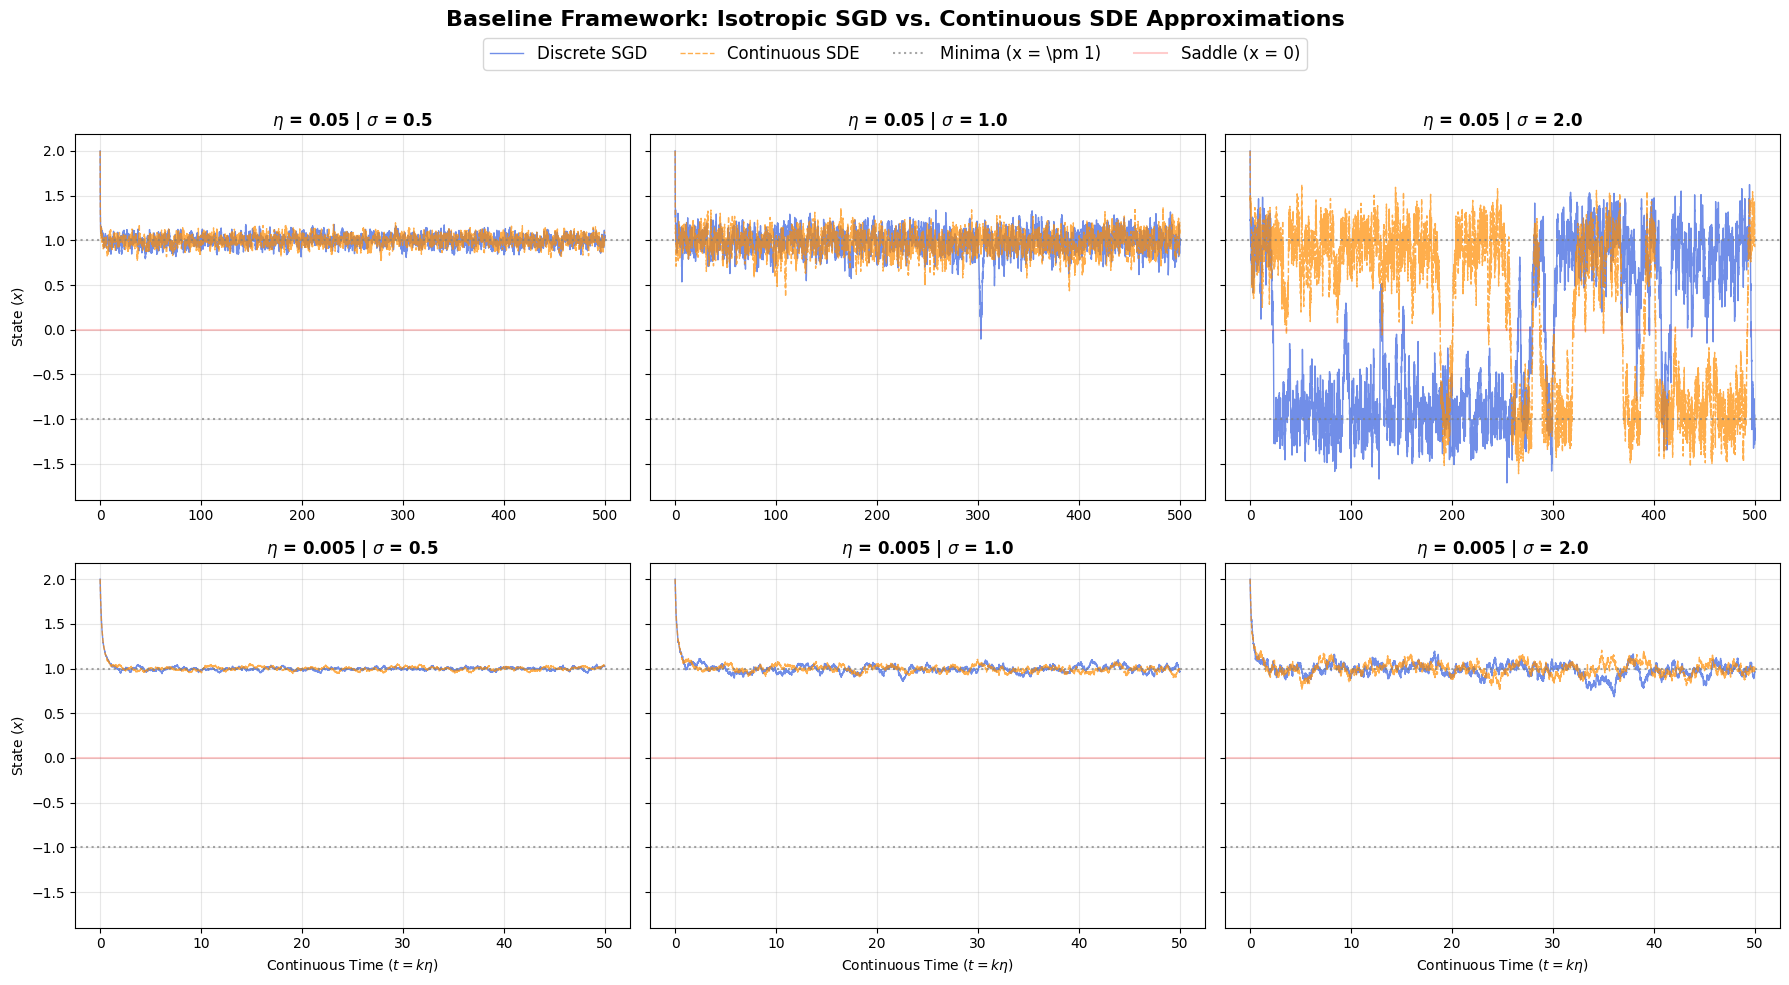

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Double-Well Potential
def f(x):
    return 0.25 * x**4 - 0.5 * x**2

# Double-Well Potential gradient
def grad_f(x):
    return x**3 - x

# Simulation Parameters
eta_list = [0.05, 0.005]
sigma_list = [0.5, 1.0, 2.0]
num_steps = 10000
x0 = 2.0  # Starting positions

def simulate_discrete_sgd(sigma, eta, num_steps, x0):
    # Simulate Standard Discrete SGD (with artificial Isotropic Gaussian Noise)
    x_sgd = np.zeros(num_steps)
    x_sgd[0] = x0
    for k in range(num_steps - 1):
        noise = np.random.normal(0, sigma)
        x_sgd[k+1] = x_sgd[k] - eta * grad_f(x_sgd[k]) - eta * noise
    return x_sgd

def simulate_continuous_sde(sigma, eta, num_steps, x0):
    # Simulate Continuous SDE via Euler-Maruyama
    # To align time t = k * eta, dt = eta
    dt = eta
    D = (eta * sigma**2) / 2
    diffusion_coeff = np.sqrt(2 * D)

    x_sde = np.zeros(num_steps)
    x_sde[0] = x0
    for k in range(num_steps - 1):
        dB = np.random.normal(0, np.sqrt(dt))
        x_sde[k+1] = x_sde[k] - grad_f(x_sde[k]) * dt + diffusion_coeff * dB
    return x_sde

fig, axes = plt.subplots(len(eta_list), len(sigma_list), figsize=(18, 10), sharey=True)

for idx_eta, eta in enumerate(eta_list):
    for idx_sigma, sigma in enumerate(sigma_list):
        
        ax = axes[idx_eta, idx_sigma]
        
        x_sgd = simulate_discrete_sgd(sigma, eta, num_steps, x0)
        x_sde = simulate_continuous_sde(sigma, eta, num_steps, x0)
        
        time_axis = np.arange(num_steps) * eta
        
        ax.plot(time_axis, x_sgd, label='Discrete SGD', alpha=0.75, color='royalblue', linewidth=1)
        ax.plot(time_axis, x_sde, label='Continuous SDE', alpha=0.7, linestyle='--', color='darkorange', linewidth=1)
        
        # Reference lines for the double-well minima and saddle point
        ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.7, label='Minima (x = \pm 1)' if (idx_eta==0 and idx_sigma==0) else "")
        ax.axhline(y=-1.0, color='gray', linestyle=':', alpha=0.7)
        ax.axhline(y=0.0, color='red', linestyle='-', alpha=0.2, label='Saddle (x = 0)' if (idx_eta==0 and idx_sigma==0) else "")
        
        ax.set_title(f"$\eta$ = {eta} | $\sigma$ = {sigma}", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        if idx_eta == len(eta_list) - 1:
            ax.set_xlabel("Continuous Time ($t = k\eta$)", fontsize=10)
        if idx_sigma == 0:
            ax.set_ylabel("State ($x$)", fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=4, fontsize=12)

plt.suptitle("Baseline Framework: Isotropic SGD vs. Continuous SDE Approximations", y=0.98, fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])  # Adjust padding to clear the layout title/legend
plt.show()

# Stochastic Properties of SGD

...